# Atividade 03 - Filtragem de Imagens e Analise de Ruido

## 1. Introducao

Imagens reais quase nunca chegam perfeitas para uma etapa de processamento. Mesmo quando a cena foi bem capturada, ainda podem aparecer ruido do sensor, granulacao, pequenas variacoes aleatorias de intensidade e artefatos de compressao. Esses efeitos alteram o valor dos pixels e podem esconder detalhes importantes da cena.

Em visao computacional, essa degradacao interfere diretamente em tarefas como segmentacao, deteccao de bordas e classificacao. Quando o ruido aumenta, o algoritmo pode interpretar variacoes aleatorias como se fossem contornos, texturas ou objetos reais.

## 2. Objetivo

Nesta atividade, serao utilizadas duas imagens autorais do dataset anterior: `sapato_01.jpg` e `skate_01.jpg`. A proposta e analisar o comportamento dessas imagens no dominio espacial e no dominio da frequencia por meio de:

- ruido gaussiano
- ruido sal e pimenta
- espectro de Fourier
- filtro passa-baixa gaussiano
- filtro passa-alta
- comparacao visual
- tabela de resultados
- conclusao critica

## 3. Importacao das bibliotecas

In [1]:
from pathlib import Path
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['axes.titlesize'] = 11

In [2]:
try:
    import google.colab
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

if EM_COLAB:
    BASE_DIR = Path('/content/visao-computacional-ex03')
    if not BASE_DIR.exists():
        subprocess.run(
            ['git', 'clone', 'https://github.com/limasantoss/visao-computacional-ex03.git', str(BASE_DIR)],
            check=True
        )
else:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == 'notebooks':
        BASE_DIR = BASE_DIR.parent

PASTA_IMAGENS = BASE_DIR / 'imagens' / 'originais'
PASTA_PROCESSADAS = BASE_DIR / 'imagens' / 'processadas'
CAMINHO_SAPATO = PASTA_IMAGENS / 'sapato_01.jpg'
CAMINHO_SKATE = PASTA_IMAGENS / 'skate_01.jpg'

print('Executando no Colab:', EM_COLAB)
print('Diretorio base:', BASE_DIR)
print('Imagem sapato existe:', CAMINHO_SAPATO.exists())
print('Imagem skate existe:', CAMINHO_SKATE.exists())

Executando no Colab: False
Diretorio base: C:\Github\visao-computacional-ex03
Imagem sapato existe: True
Imagem skate existe: True


## 4. Carregamento das imagens

In [3]:
def carregar_imagem_cinza(caminho):
    caminho = Path(caminho)
    if not caminho.exists():
        raise FileNotFoundError(f'Arquivo nao encontrado: {caminho}')

    with Image.open(caminho) as img:
        imagem_cinza = img.convert('L')
        return np.array(imagem_cinza, dtype=np.uint8)


sapato = carregar_imagem_cinza(CAMINHO_SAPATO)
skate = carregar_imagem_cinza(CAMINHO_SKATE)

print(f'Sapato carregado com shape {sapato.shape} e dtype {sapato.dtype}')
print(f'Skate carregado com shape {skate.shape} e dtype {skate.dtype}')

Sapato carregado com shape (1200, 1600) e dtype uint8
Skate carregado com shape (1600, 1200) e dtype uint8


## 5. Exibicao das imagens originais

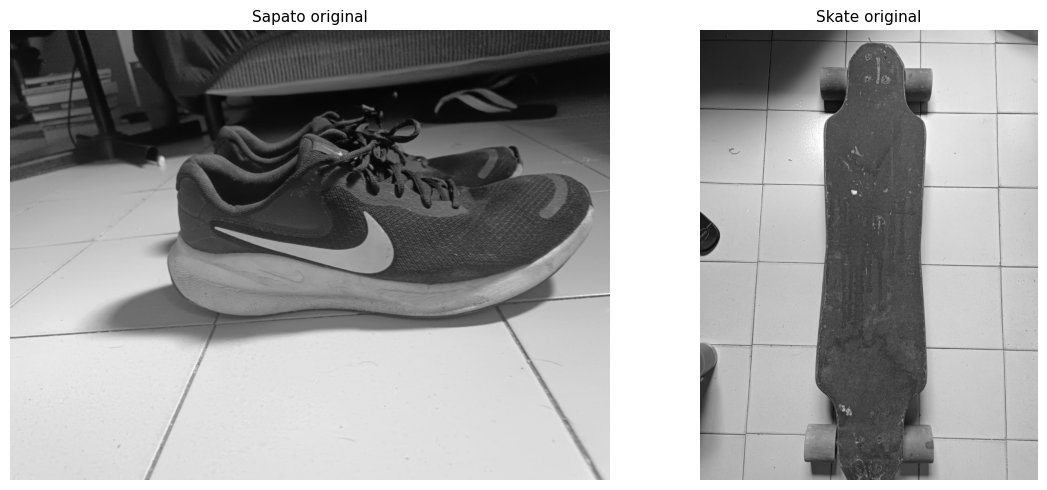

In [4]:
def mostrar_duas_imagens(imagem_a, titulo_a, imagem_b, titulo_b, cmap='gray'):
    fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
    eixos[0].imshow(imagem_a, cmap=cmap)
    eixos[0].set_title(titulo_a)
    eixos[0].axis('off')

    eixos[1].imshow(imagem_b, cmap=cmap)
    eixos[1].set_title(titulo_b)
    eixos[1].axis('off')

    plt.tight_layout()
    plt.show()


mostrar_duas_imagens(sapato, 'Sapato original', skate, 'Skate original')

## 6. Espectro de Fourier

A imagem original esta no dominio espacial, ou seja, cada valor representa diretamente a intensidade de um pixel. Quando aplicamos a Transformada Rapida de Fourier (FFT), a representacao passa para o dominio da frequencia.

No espectro centralizado, a regiao do centro concentra as frequencias baixas, normalmente associadas a areas mais suaves e variacoes lentas de intensidade. As partes mais afastadas do centro representam frequencias altas, ligadas a bordas, detalhes finos e tambem ao ruido.

In [5]:
def calcular_espectro(imagem):
    fft = np.fft.fft2(imagem)
    fft_centralizada = np.fft.fftshift(fft)
    espectro = np.log1p(np.abs(fft_centralizada))
    return espectro


def mostrar_imagem_e_espectro(imagem, titulo):
    espectro = calcular_espectro(imagem)
    fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

    eixos[0].imshow(imagem, cmap='gray')
    eixos[0].set_title(titulo)
    eixos[0].axis('off')

    eixos[1].imshow(espectro, cmap='gray')
    eixos[1].set_title(f'Espectro - {titulo}')
    eixos[1].axis('off')

    plt.tight_layout()
    plt.show()

## 7. Espectro das imagens originais

Nas duas imagens, a expectativa e encontrar maior concentracao de energia perto do centro do espectro, porque boa parte da cena ainda e formada por superficies continuas e variacoes mais suaves. Se aparecerem tracos mais definidos ou estruturas em cruz, isso costuma indicar direcoes dominantes de bordas e contraste natural da imagem.

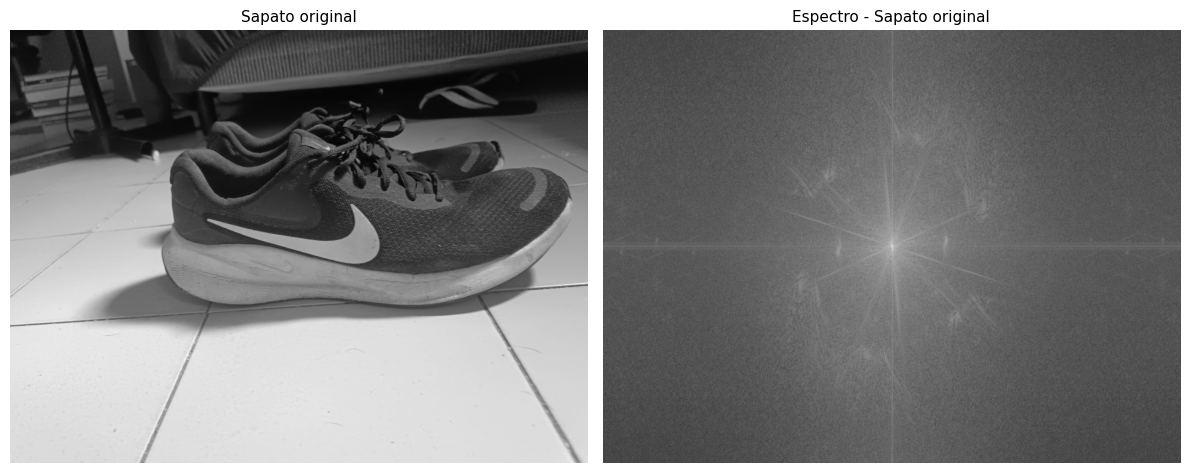

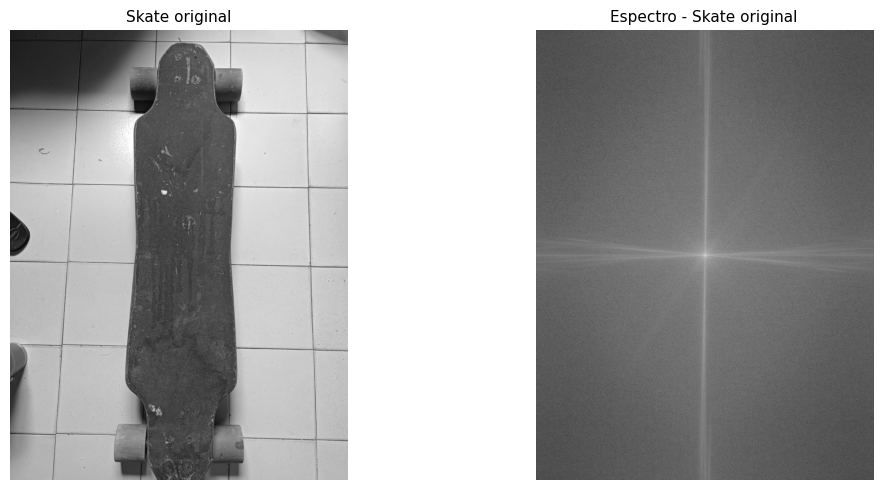

In [6]:
mostrar_imagem_e_espectro(sapato, 'Sapato original')
mostrar_imagem_e_espectro(skate, 'Skate original')

## 8. Ruido gaussiano

O ruido gaussiano costuma aparecer como uma granulacao distribuida pela imagem inteira. Quando o desvio padrao aumenta, essa perturbacao fica mais visivel porque os pixels passam a sofrer variacoes mais intensas. Isso pode atrapalhar segmentacao e classificacao, ja que a intensidade deixa de representar apenas a estrutura real da cena.

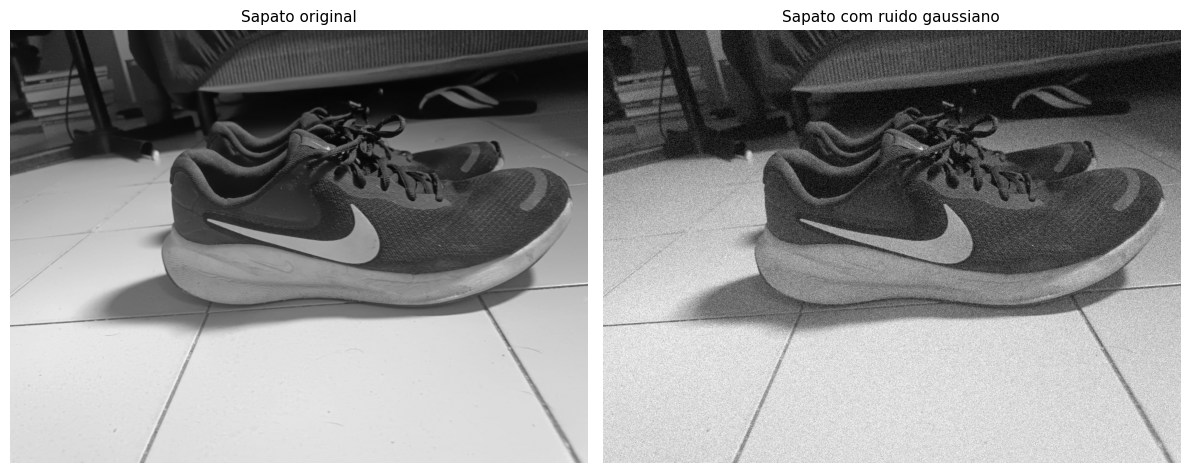

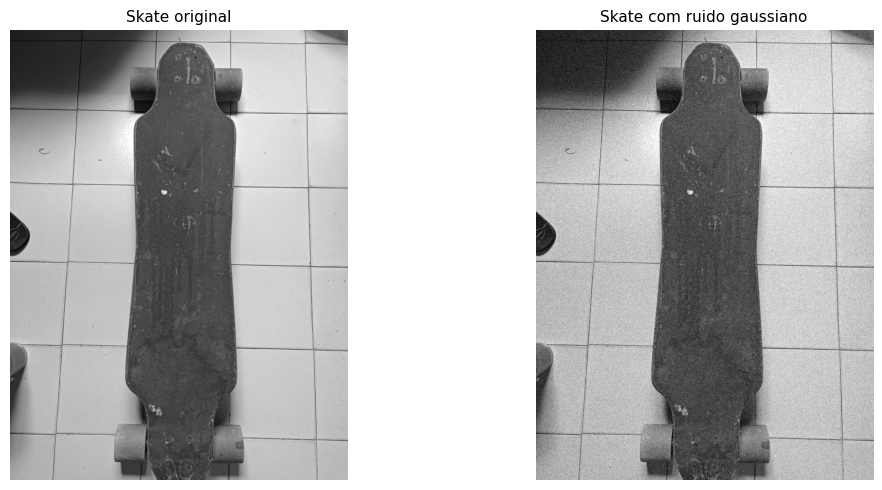

In [7]:
def adicionar_ruido_gaussiano(imagem, media=0, desvio=25, seed=42):
    rng = np.random.default_rng(seed)
    ruido = rng.normal(media, desvio, size=imagem.shape)
    imagem_ruidosa = imagem.astype(np.float32) + ruido
    imagem_ruidosa = np.clip(imagem_ruidosa, 0, 255)
    return imagem_ruidosa.astype(np.uint8)


sapato_gaussiano = adicionar_ruido_gaussiano(sapato, media=0, desvio=25, seed=42)
skate_gaussiano = adicionar_ruido_gaussiano(skate, media=0, desvio=25, seed=43)

mostrar_duas_imagens(sapato, 'Sapato original', sapato_gaussiano, 'Sapato com ruido gaussiano')
mostrar_duas_imagens(skate, 'Skate original', skate_gaussiano, 'Skate com ruido gaussiano')

## 9. Ruido sal e pimenta

O ruido sal e pimenta gera pontos pretos e brancos espalhados pela imagem. Como esses pontos criam contrastes muito fortes em areas pequenas, eles podem produzir bordas falsas e prejudicar algoritmos que dependem de contornos bem definidos.

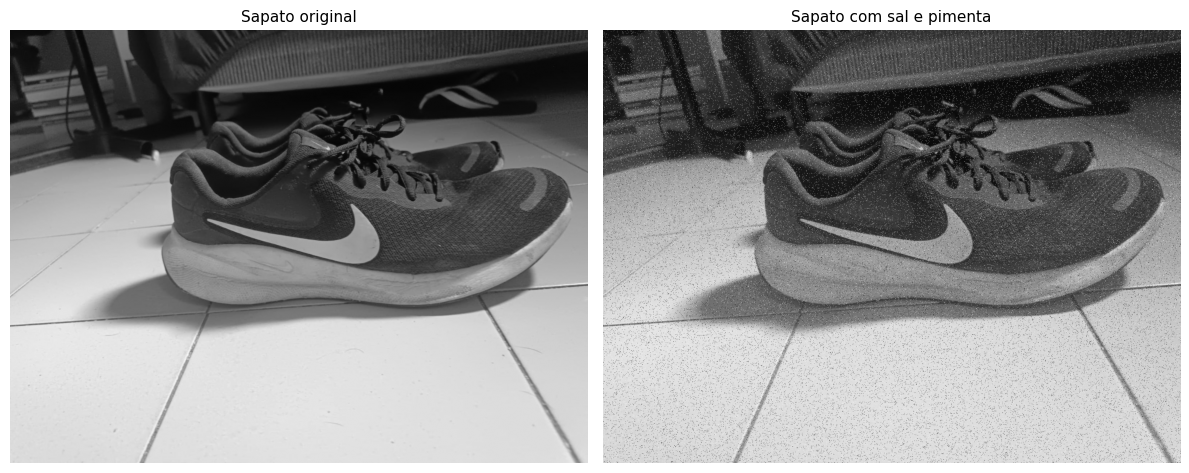

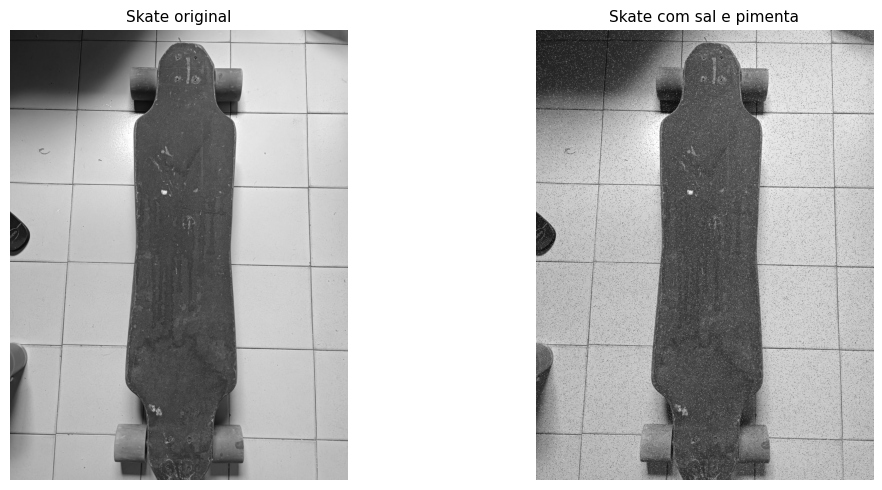

In [8]:
def adicionar_ruido_sal_pimenta(imagem, quantidade=0.05, seed=42):
    rng = np.random.default_rng(seed)
    imagem_ruidosa = imagem.copy()

    total_pixels = imagem.size
    quantidade_pixels = int(total_pixels * quantidade)
    indices = rng.choice(total_pixels, size=quantidade_pixels, replace=False)

    metade = quantidade_pixels // 2
    linhas_sal, colunas_sal = np.unravel_index(indices[:metade], imagem.shape)
    linhas_pimenta, colunas_pimenta = np.unravel_index(indices[metade:], imagem.shape)

    imagem_ruidosa[linhas_sal, colunas_sal] = 255
    imagem_ruidosa[linhas_pimenta, colunas_pimenta] = 0
    return imagem_ruidosa.astype(np.uint8)


sapato_sal_pimenta = adicionar_ruido_sal_pimenta(sapato, quantidade=0.05, seed=42)
skate_sal_pimenta = adicionar_ruido_sal_pimenta(skate, quantidade=0.05, seed=43)

mostrar_duas_imagens(sapato, 'Sapato original', sapato_sal_pimenta, 'Sapato com sal e pimenta')
mostrar_duas_imagens(skate, 'Skate original', skate_sal_pimenta, 'Skate com sal e pimenta')

## 10. Espectro das imagens com ruido

Quando o ruido e adicionado, parte da energia se espalha pelo espectro e aparecem componentes mais aleatorios em regioes de alta frequencia. Na pratica, o espectro fica mais caotico e menos concentrado apenas nas estruturas naturais da cena.

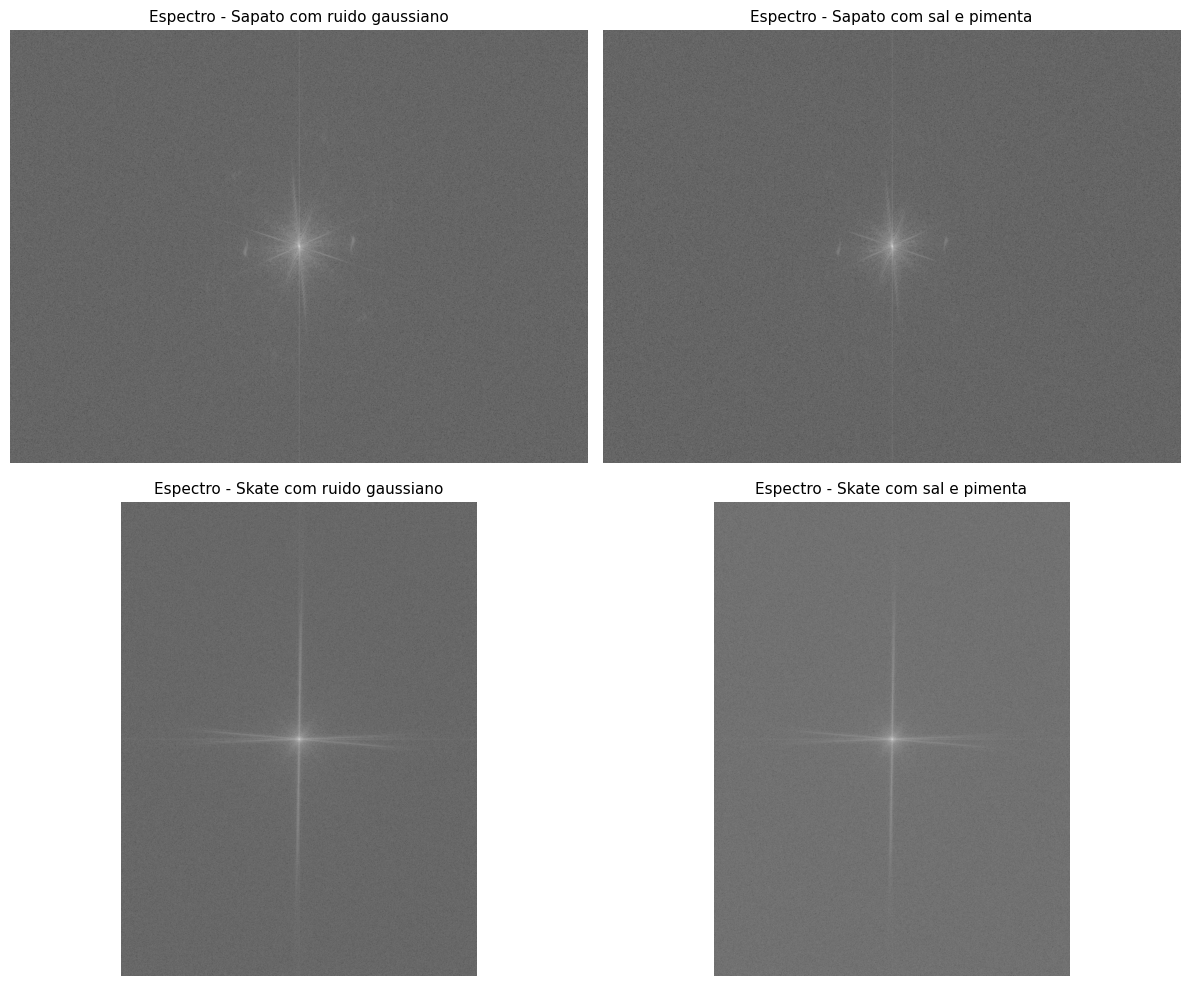

In [9]:
fig, eixos = plt.subplots(2, 2, figsize=(12, 10))
pares = [
    (sapato_gaussiano, 'Sapato com ruido gaussiano'),
    (sapato_sal_pimenta, 'Sapato com sal e pimenta'),
    (skate_gaussiano, 'Skate com ruido gaussiano'),
    (skate_sal_pimenta, 'Skate com sal e pimenta'),
]

for eixo, (imagem, titulo) in zip(eixos.ravel(), pares):
    eixo.imshow(calcular_espectro(imagem), cmap='gray')
    eixo.set_title(f'Espectro - {titulo}')
    eixo.axis('off')

plt.tight_layout()
plt.show()

## 11. Filtro passa-baixa gaussiano

O filtro passa-baixa gaussiano mantem maior peso nas baixas frequencias, que ficam concentradas no centro do espectro, e reduz gradualmente as altas frequencias. Isso ajuda a suavizar ruido e detalhes muito finos.

Em geral, um `sigma` menor suaviza mais, mas tambem tende a borrar mais a imagem. Um `sigma` maior preserva melhor as formas principais, embora possa deixar parte do ruido passar.

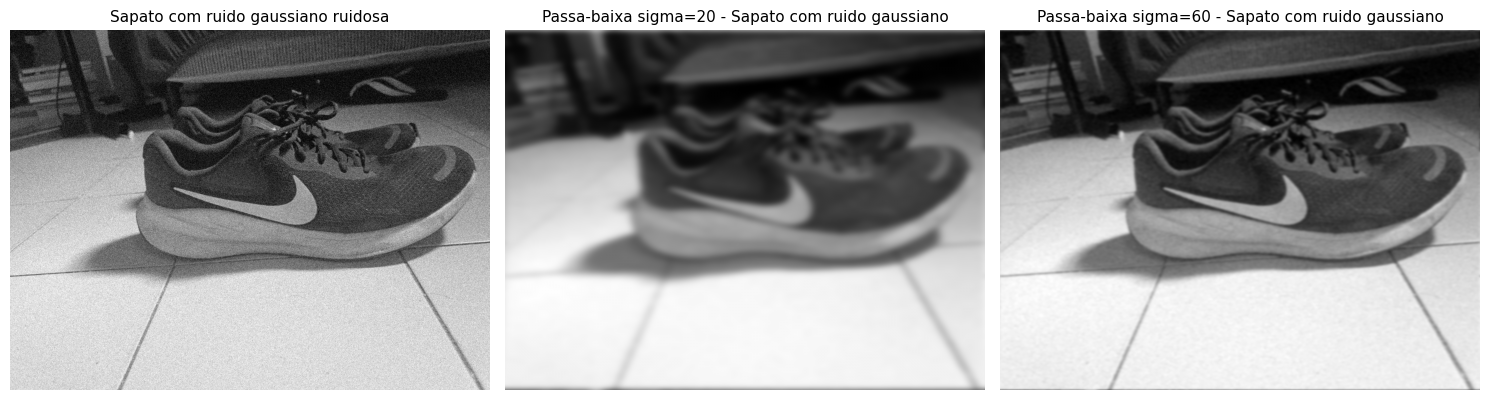

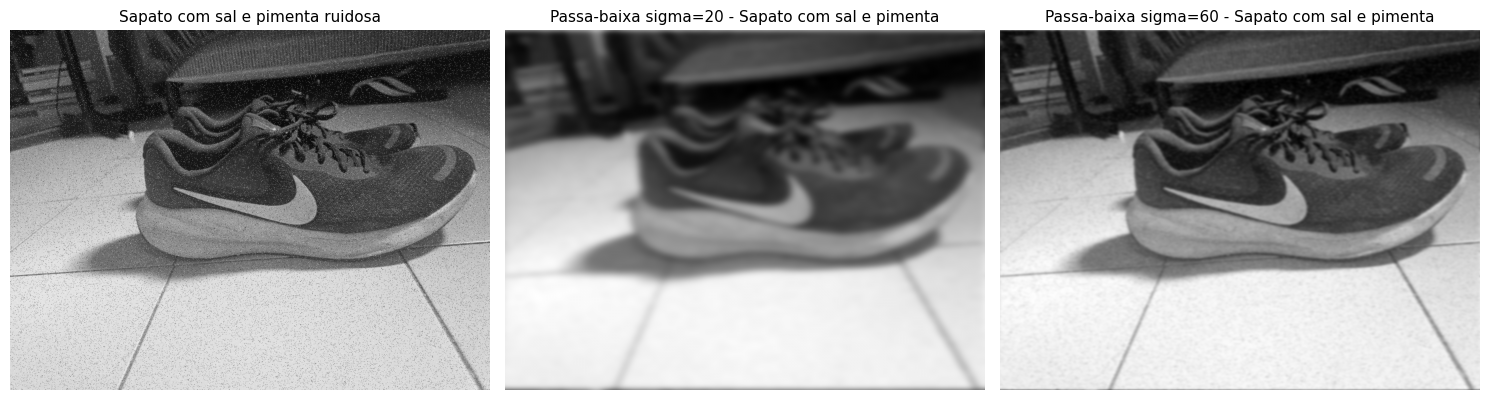

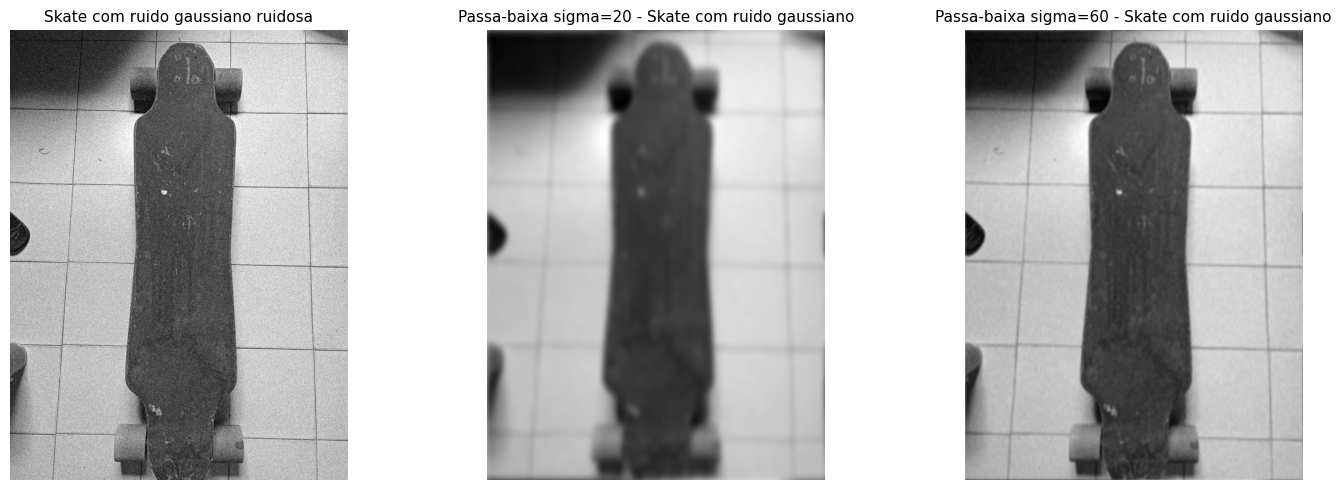

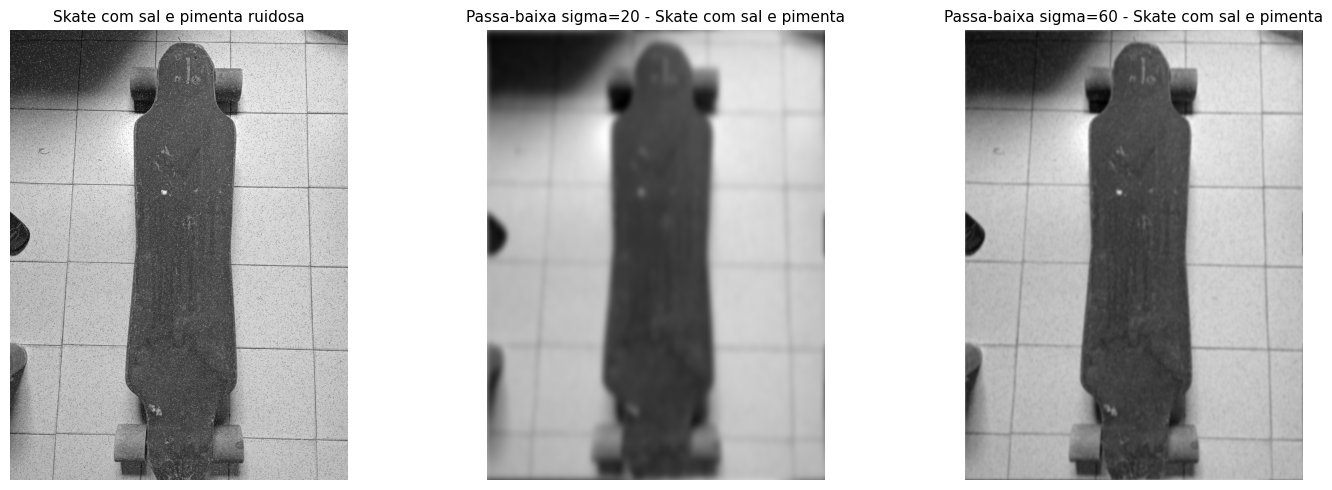

In [10]:
def criar_filtro_passa_baixa_gaussiano(shape, sigma):
    linhas, colunas = shape
    y, x = np.ogrid[:linhas, :colunas]
    centro_y, centro_x = linhas // 2, colunas // 2
    distancia_quadrada = (y - centro_y) ** 2 + (x - centro_x) ** 2
    filtro = np.exp(-distancia_quadrada / (2 * (sigma ** 2)))
    return filtro.astype(np.float32)


def aplicar_filtro_frequencia(imagem, filtro):
    fft = np.fft.fft2(imagem)
    fft_centralizada = np.fft.fftshift(fft)
    fft_filtrada = fft_centralizada * filtro
    fft_reposicionada = np.fft.ifftshift(fft_filtrada)
    imagem_filtrada = np.abs(np.fft.ifft2(fft_reposicionada))

    imagem_filtrada = imagem_filtrada - imagem_filtrada.min()
    if imagem_filtrada.max() > 0:
        imagem_filtrada = imagem_filtrada / imagem_filtrada.max() * 255

    return imagem_filtrada.astype(np.uint8)


def mostrar_resultados_passa_baixa(imagem_ruidosa, titulo_base):
    filtro_20 = criar_filtro_passa_baixa_gaussiano(imagem_ruidosa.shape, sigma=20)
    filtro_60 = criar_filtro_passa_baixa_gaussiano(imagem_ruidosa.shape, sigma=60)
    imagem_20 = aplicar_filtro_frequencia(imagem_ruidosa, filtro_20)
    imagem_60 = aplicar_filtro_frequencia(imagem_ruidosa, filtro_60)

    fig, eixos = plt.subplots(1, 3, figsize=(15, 5))
    eixos[0].imshow(imagem_ruidosa, cmap='gray')
    eixos[0].set_title(f'{titulo_base} ruidosa')
    eixos[0].axis('off')

    eixos[1].imshow(imagem_20, cmap='gray')
    eixos[1].set_title(f'Passa-baixa sigma=20 - {titulo_base}')
    eixos[1].axis('off')

    eixos[2].imshow(imagem_60, cmap='gray')
    eixos[2].set_title(f'Passa-baixa sigma=60 - {titulo_base}')
    eixos[2].axis('off')

    plt.tight_layout()
    plt.show()

    return imagem_20, imagem_60


sapato_pb_gauss_20, sapato_pb_gauss_60 = mostrar_resultados_passa_baixa(sapato_gaussiano, 'Sapato com ruido gaussiano')
sapato_pb_sp_20, sapato_pb_sp_60 = mostrar_resultados_passa_baixa(sapato_sal_pimenta, 'Sapato com sal e pimenta')
skate_pb_gauss_20, skate_pb_gauss_60 = mostrar_resultados_passa_baixa(skate_gaussiano, 'Skate com ruido gaussiano')
skate_pb_sp_20, skate_pb_sp_60 = mostrar_resultados_passa_baixa(skate_sal_pimenta, 'Skate com sal e pimenta')

Na comparacao visual, o `sigma=20` tende a suavizar de forma mais agressiva e borrar melhor os detalhes finos. Ja o `sigma=60` costuma equilibrar melhor reducao de ruido e preservacao da forma geral, embora ainda mantenha uma parte das altas frequencias.

## 12. Filtro passa-alta gaussiano

O filtro passa-alta pode ser obtido como o complemento do passa-baixa. Assim, as regioes de baixa frequencia sao enfraquecidas e as componentes de alta frequencia ganham destaque.

Esse comportamento e util para realcar bordas, detalhes e transicoes rapidas de intensidade, mas ele tambem evidencia o proprio ruido. Por isso, o passa-alta nao e a melhor escolha para remover degradacoes, e sim para destacar contornos.

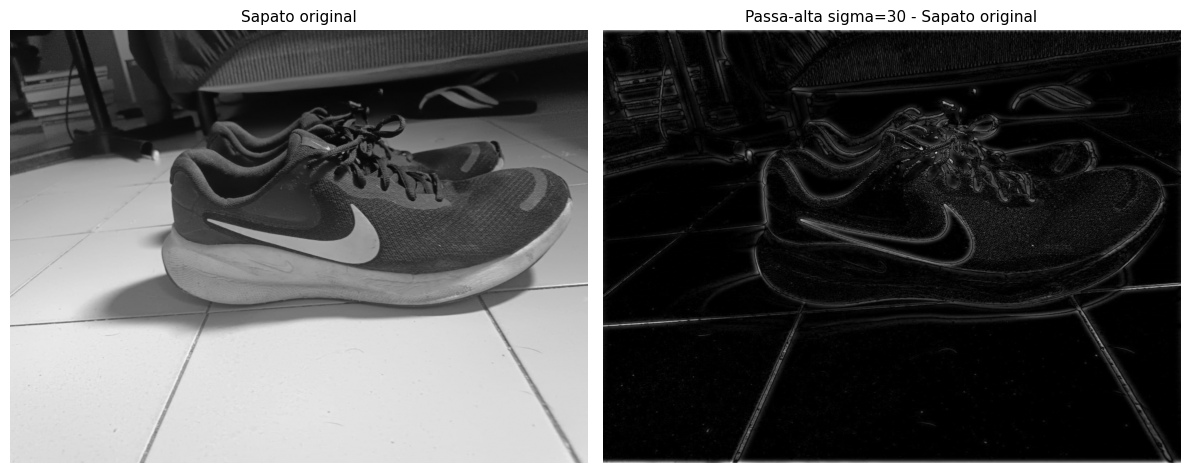

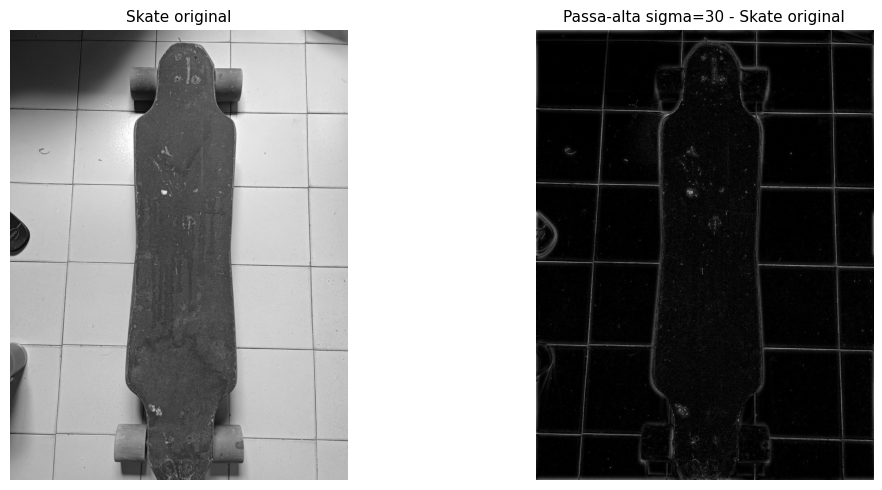

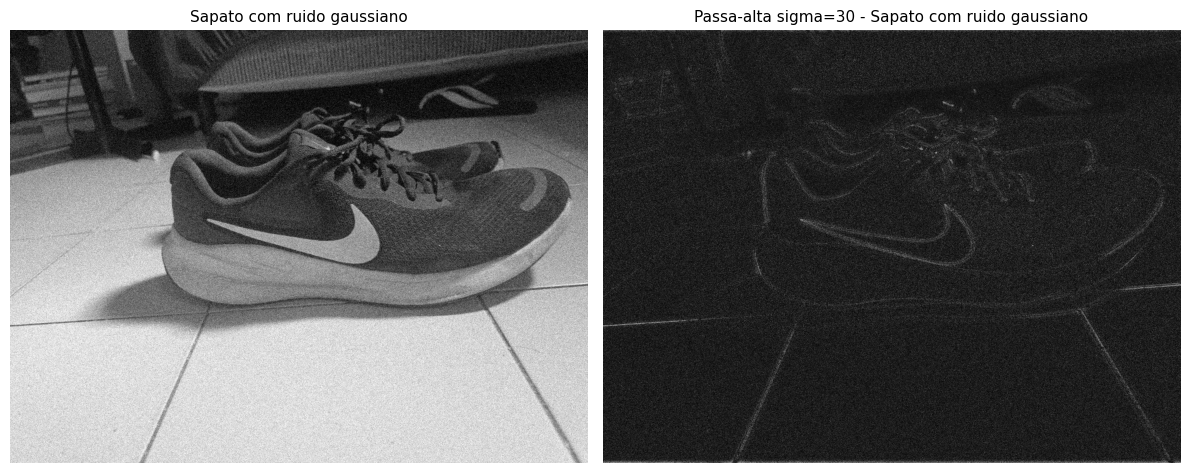

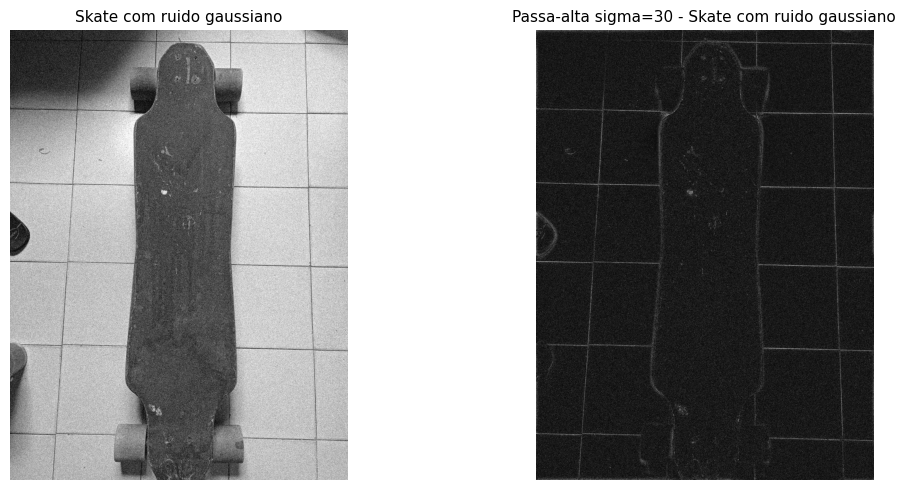

In [11]:
def criar_filtro_passa_alta_gaussiano(shape, sigma):
    passa_baixa = criar_filtro_passa_baixa_gaussiano(shape, sigma=sigma)
    passa_alta = 1 - passa_baixa
    return passa_alta.astype(np.float32)


def mostrar_resultado_passa_alta(imagem, titulo, sigma=30):
    filtro = criar_filtro_passa_alta_gaussiano(imagem.shape, sigma=sigma)
    resultado = aplicar_filtro_frequencia(imagem, filtro)

    fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
    eixos[0].imshow(imagem, cmap='gray')
    eixos[0].set_title(titulo)
    eixos[0].axis('off')

    eixos[1].imshow(resultado, cmap='gray')
    eixos[1].set_title(f'Passa-alta sigma={sigma} - {titulo}')
    eixos[1].axis('off')

    plt.tight_layout()
    plt.show()
    return resultado


sapato_passa_alta = mostrar_resultado_passa_alta(sapato, 'Sapato original', sigma=30)
skate_passa_alta = mostrar_resultado_passa_alta(skate, 'Skate original', sigma=30)
sapato_gaussiano_passa_alta = mostrar_resultado_passa_alta(sapato_gaussiano, 'Sapato com ruido gaussiano', sigma=30)
skate_gaussiano_passa_alta = mostrar_resultado_passa_alta(skate_gaussiano, 'Skate com ruido gaussiano', sigma=30)

## 13. Metricas simples

Para a tabela principal de metricas, foi usada a versao com passa-baixa `sigma=60` aplicada sobre a imagem com ruido gaussiano. Essa escolha preservou melhor a leitura geral das formas, sem chegar ao borramento mais forte observado com `sigma=20`.

In [12]:
def calcular_metricas(imagem):
    imagem_float = imagem.astype(np.float32)
    return {
        'media': float(np.mean(imagem_float)),
        'variancia': float(np.var(imagem_float)),
        'desvio_padrao': float(np.std(imagem_float)),
        'minimo': int(np.min(imagem_float)),
        'maximo': int(np.max(imagem_float)),
    }


metricas = pd.DataFrame(
    {
        'sapato original': calcular_metricas(sapato),
        'sapato ruido gaussiano': calcular_metricas(sapato_gaussiano),
        'sapato sal e pimenta': calcular_metricas(sapato_sal_pimenta),
        'sapato passa-baixa': calcular_metricas(sapato_pb_gauss_60),
        'sapato passa-alta': calcular_metricas(sapato_passa_alta),
        'skate original': calcular_metricas(skate),
        'skate ruido gaussiano': calcular_metricas(skate_gaussiano),
        'skate sal e pimenta': calcular_metricas(skate_sal_pimenta),
        'skate passa-baixa': calcular_metricas(skate_pb_gauss_60),
        'skate passa-alta': calcular_metricas(skate_passa_alta),
    }
).T.round(2)

metricas

,media,variancia,desvio_padrao,minimo,maximo
sapato original,133.03,5829.30,76.35,4.0,251.0
sapato ruido gaussiano,132.66,6250.48,79.06,0.0,255.0
sapato sal e pimenta,132.76,6352.67,79.70,0.0,255.0
sapato passa-baixa,140.26,7604.91,87.21,0.0,255.0
sapato passa-alta,11.75,415.55,20.39,0.0,255.0
skate original,152.75,3897.55,62.43,2.0,255.0
skate ruido gaussiano,152.10,4463.63,66.81,0.0,255.0
skate sal e pimenta,151.49,4546.35,67.43,0.0,255.0
skate passa-baixa,149.48,4713.27,68.65,0.0,255.0
skate passa-alta,9.24,323.95,18.00,0.0,255.0


Os numeros reforcam a leitura visual: o ruido tende a alterar variancia e desvio padrao, enquanto o passa-baixa reduz parte dessas variacoes ao custo de menos nitidez. O passa-alta destaca transicoes e detalhes, o que costuma deslocar a distribuicao de intensidades para estruturas mais contrastadas.

## 14. Tabela final obrigatoria de resultados observados

In [13]:
tabela_resultados = pd.DataFrame(
    [
        {
            'Imagem/processamento': 'Imagem original',
            'Resultado observado': 'Sapato e skate preservam textura, iluminacao e bordas naturais da cena.',
            'Impacto em visao computacional': 'Serve como referencia mais fiel para segmentacao, extracao de bordas e classificacao.'
        },
        {
            'Imagem/processamento': 'Imagem com ruido gaussiano',
            'Resultado observado': 'Nas duas imagens aparece uma granulacao distribuida, deixando a superficie menos uniforme.',
            'Impacto em visao computacional': 'Pode confundir classificadores e aumentar falsas variacoes em etapas de analise.'
        },
        {
            'Imagem/processamento': 'Imagem com ruido sal e pimenta',
            'Resultado observado': 'Surgem pontos pretos e brancos isolados em sapato e skate, com contraste bem agressivo.',
            'Impacto em visao computacional': 'Cria bordas falsas e atrapalha detectores sensiveis a transicoes abruptas.'
        },
        {
            'Imagem/processamento': 'Imagem filtrada com passa-baixa gaussiano',
            'Resultado observado': 'O ruido diminui nas duas imagens, mas alguns contornos ficam mais suaves, principalmente com sigma menor.',
            'Impacto em visao computacional': 'Ajuda na suavizacao antes de outras etapas, porem pode apagar detalhes relevantes.'
        },
        {
            'Imagem/processamento': 'Imagem filtrada com passa-alta',
            'Resultado observado': 'Bordas e detalhes do sapato e do skate ficam mais destacados, junto com parte do ruido.',
            'Impacto em visao computacional': 'E util para realce de contornos, mas nao e indicado quando o objetivo principal e remover ruido.'
        },
    ]
)

tabela_resultados

,Imagem/processamento,Resultado observado,Impacto em visao computacional
0,Imagem original,"Sapato e skate preservam textura, iluminacao e...",Serve como referencia mais fiel para segmentac...
1,Imagem com ruido gaussiano,Nas duas imagens aparece uma granulacao distri...,Pode confundir classificadores e aumentar fals...
2,Imagem com ruido sal e pimenta,Surgem pontos pretos e brancos isolados em sap...,Cria bordas falsas e atrapalha detectores sens...
3,Imagem filtrada com passa-baixa gaussiano,"O ruido diminui nas duas imagens, mas alguns c...","Ajuda na suavizacao antes de outras etapas, po..."
4,Imagem filtrada com passa-alta,Bordas e detalhes do sapato e do skate ficam m...,"E util para realce de contornos, mas nao e ind..."


## 15. Conclusao critica

Nas imagens analisadas, o ruido sal e pimenta foi o que degradou mais a leitura visual porque criou pontos extremos muito artificiais, principalmente em areas que antes eram mais continuas. O ruido gaussiano tambem prejudicou a qualidade, mas de um jeito mais espalhado e menos agressivo que o sal e pimenta.

O filtro que mais ajudou na suavizacao foi o passa-baixa gaussiano, especialmente na configuracao com `sigma=60`, que conseguiu reduzir parte do ruido sem destruir totalmente a estrutura principal do objeto. Mesmo assim, ficou claro que depois do passa-baixa alguns detalhes finos e contornos perderam nitidez, mostrando que suavizar demais tambem tem custo.

Ja o passa-alta destacou bordas, transicoes rapidas e partes de textura, mas tambem evidenciou o proprio ruido quando a imagem ja estava degradada. Isso importa para tarefas futuras de visao computacional porque etapas como segmentacao, deteccao de bordas e classificacao dependem de um equilibrio entre remover interferencias e preservar informacoes uteis da cena. Se o filtro for forte demais, detalhes importantes podem desaparecer; se for fraco demais, o ruido continua atrapalhando a analise.